# Playground Series - S3E15: Synthetic Dataset Project

## Introduction
This project involves using a synthetically-generated dataset for analysis and prediction. The aim is to apply machine learning techniques to solve the problem, experiment with feature engineering, and model selection. The dataset has been generated from real-world data, providing a unique opportunity to work with both familiar data types and synthetic features. The dataset can be downloaded from the [Kaggle competition page](https://www.kaggle.com/competitions/playground-series-s3e15/data).


In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv("data.csv")

In [6]:
df.head()

,id,author,geometry,pressure [MPa],mass_flux [kg/m2-s],x_e_out [-],D_e [mm],D_h [mm],length [mm],chf_exp [MW/m2]
0,0,Thompson,tube,7.00,3770.0,0.1754,NaN,10.8,432.0,3.6
1,1,Thompson,tube,NaN,6049.0,-0.0416,10.3,10.3,762.0,6.2
2,2,Thompson,NaN,13.79,2034.0,0.0335,7.7,7.7,457.0,2.5
3,3,Beus,annulus,13.79,3679.0,-0.0279,5.6,15.2,2134.0,3.0
4,4,NaN,tube,13.79,686.0,NaN,11.1,11.1,457.0,2.8


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31644 entries, 0 to 31643
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   31644 non-null  int64  
 1   author               26620 non-null  object 
 2   geometry             26144 non-null  object 
 3   pressure [MPa]       27192 non-null  float64
 4   mass_flux [kg/m2-s]  26853 non-null  float64
 5   x_e_out [-]          21229 non-null  float64
 6   D_e [mm]             26156 non-null  float64
 7   D_h [mm]             27055 non-null  float64
 8   length [mm]          26885 non-null  float64
 9   chf_exp [MW/m2]      31644 non-null  float64
dtypes: float64(7), int64(1), object(2)
memory usage: 2.4+ MB


In [10]:
df.shape

(31644, 10)

In [14]:
df.isnull().sum()

id                         0
author                  5024
geometry                5500
pressure [MPa]          4452
mass_flux [kg/m2-s]     4791
x_e_out [-]            10415
D_e [mm]                5488
D_h [mm]                4589
length [mm]             4759
chf_exp [MW/m2]            0
dtype: int64

In [20]:
df = df.rename(columns={'pressure [MPa]':'pressure',
                           'mass_flux [kg/m2-s]':'mass_flux',
                           'x_e_out [-]':'x_e_out',
                           'D_e [mm]':'D_e',
                           'D_h [mm]':'D_h',
                           'length [mm]':'length',
                           'chf_exp [MW/m2]':'chf_exp'})

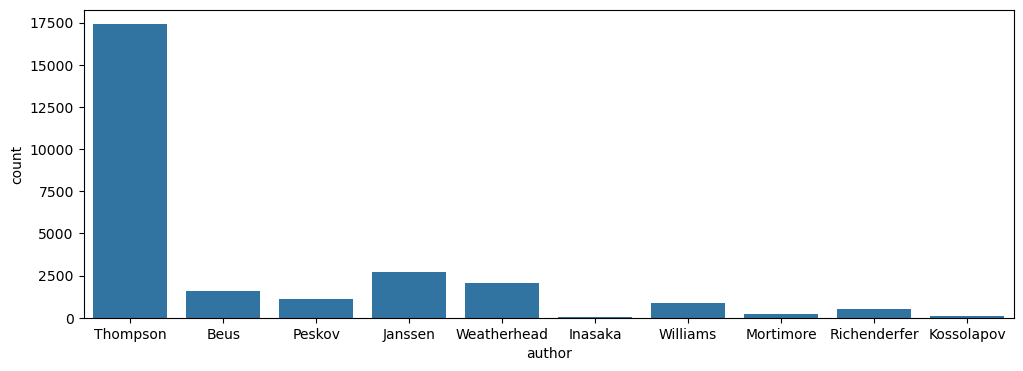

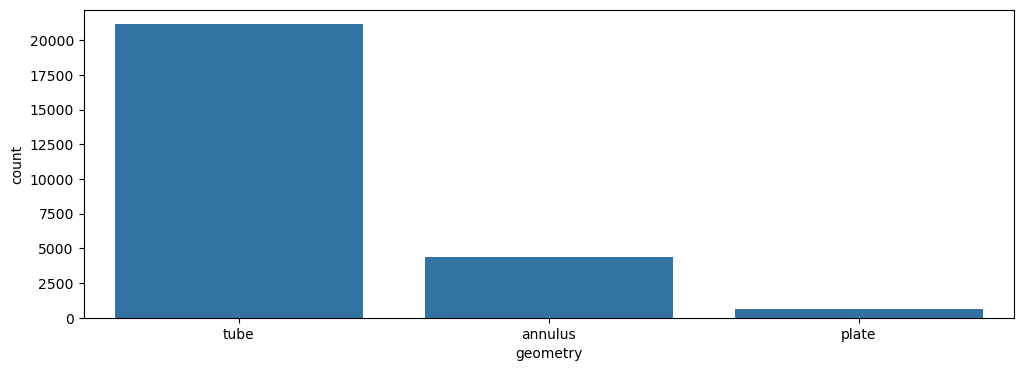

In [26]:
for col in df.columns:
    if df[col].dtype == 'object':
        plt.figure(figsize = (12,4))
        sns.countplot(x=df[col])
    plt.show()

In [28]:
print('Total missing value in Author :',df['author'].isnull().sum())
print('Total missing value in Geometry :',df['geometry'].isnull().sum())

Total missing value in Author : 5024
Total missing value in Geometry : 5500


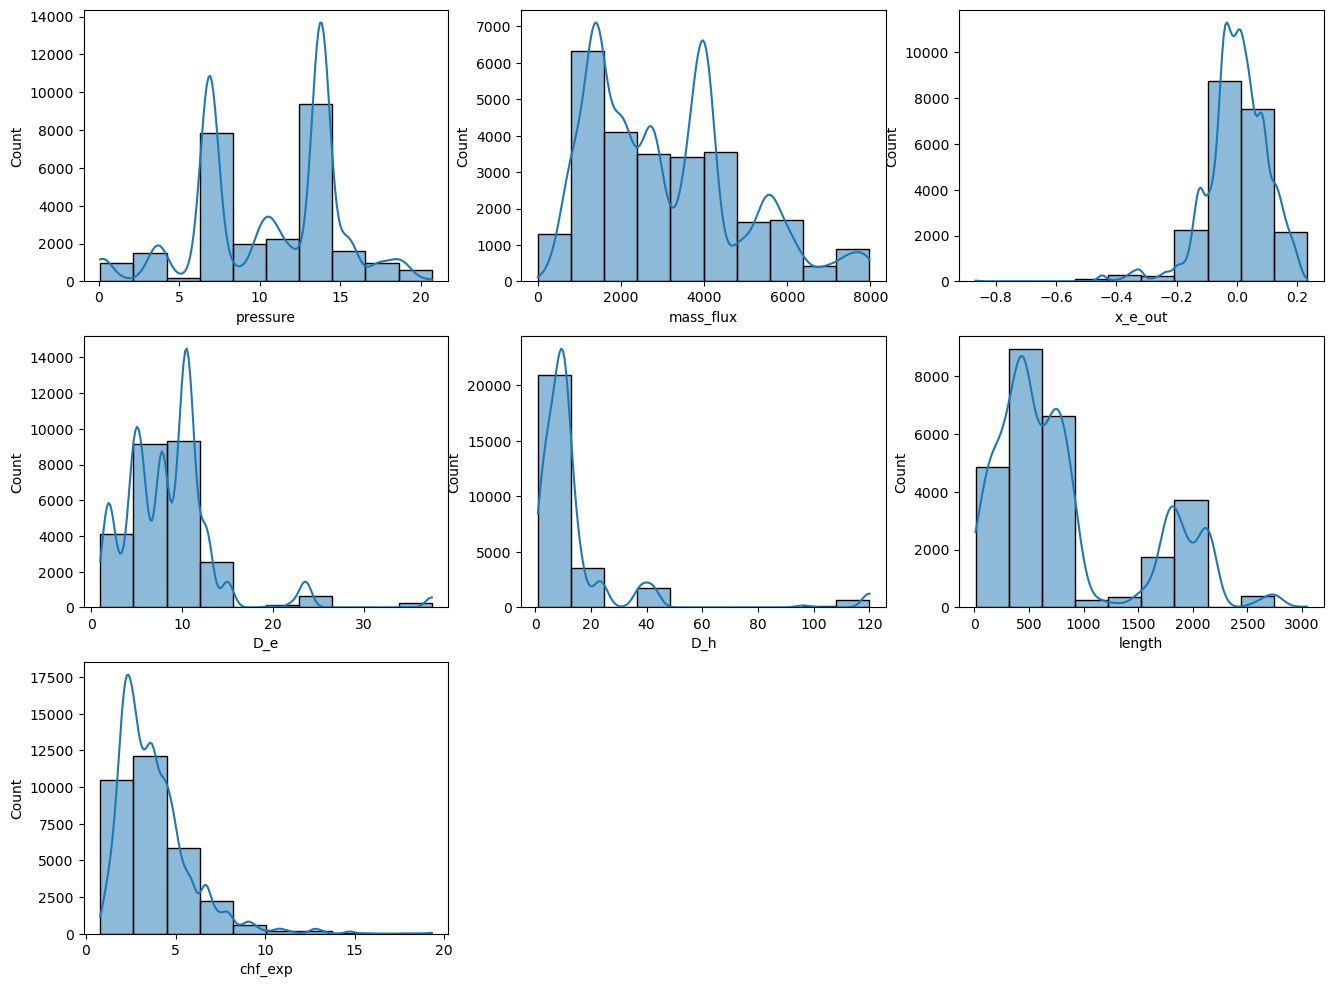

In [32]:
features = ['pressure', 'mass_flux', 'x_e_out', 'D_e', 'D_h', 'length', 'chf_exp']

plt.figure(figsize = (16,12))
for i , col in enumerate(features, 1):
    plt.subplot(3,3,i)
    sns.histplot(x = col, data = df, kde = True, bins=10) 
    plt.xlabel(col)
plt.show()

+ there is skewness

In [35]:
#  for outliers
outliers_features = ['pressure', 'mass_flux', 'D_e', 'D_h', 'length', 'chf_exp']

def replace_outliers(df):
    for i in outliers_features:
        IQR1 = df[i].quantile(0.25)
        IQR3 = df[i].quantile(0.75)
        IQR = IQR3 - IQR1
        
        median_ = df[i].median()
        lower = IQR1 - 1.5 * IQR
        upper = IQR3 + 1.5 * IQR
        
        df.loc[(df[i] < lower) | (df[i] > upper), i] = median_
    return df

df1 = replace_outliers(df)


In [37]:
author_OHE = pd.get_dummies(df1['author'], drop_first = False, dummy_na = False).astype(int)
geometry_OHE = pd.get_dummies(df1['geometry'], drop_first = False, dummy_na = False).astype(int)

In [39]:
merged_df = pd.concat([author_OHE, geometry_OHE, df1], axis=1)

In [41]:
df2 = merged_df

In [43]:
df2 = df2.drop(['author', 'geometry'], axis = 1)

In [45]:
train = df2[df2['x_e_out'].notnull()]
print('Train shape :',train.shape)
                
test = df2[df2['x_e_out'].isnull()]
print('Test shape :',test.shape)

Train shape : (21229, 21)
Test shape : (10415, 21)


In [47]:
train_without_nan = train.fillna(train.median(numeric_only=True))
test_without_nan  = test.fillna(train.median(numeric_only=True))

In [49]:
X_train = train_without_nan.drop(['x_e_out', 'id'], axis = 1) 
Y_train = train_without_nan['x_e_out']

In [51]:
X_test = test_without_nan.drop(['x_e_out', 'id'], axis = 1) 
Y_test = test_without_nan['x_e_out']

In [55]:
std = StandardScaler()
x_train = std.fit_transform(X_train)
x_test = std.transform(X_test)

In [59]:
from sklearn.metrics import r2_score


regressors = [('SVR',SVR()),
              ('DecisionTreeRegressor',DecisionTreeRegressor()),
              ('KNeighborsRegressor', KNeighborsRegressor()),
              ('RandomForestRegressor', RandomForestRegressor()),
              ('MLPRegressor',MLPRegressor()),
              ('AdaBoostRegressor',AdaBoostRegressor()),
              ('GradientBoostingRegressor',GradientBoostingRegressor())]

Acc = []

for mod in regressors:
    name = mod[0]
    model = mod[1]
    model.fit(x_train, Y_train)
    train = r2_score(Y_train, model.predict(x_train))
    Acc.append({'model': name, 'TRAIN': train})

df = pd.DataFrame(Acc, columns=['model', 'TRAIN']).sort_values(by='TRAIN')
df

,model,TRAIN
5,AdaBoostRegressor,0.087285
4,MLPRegressor,0.360255
0,SVR,0.380041
6,GradientBoostingRegressor,0.437440
2,KNeighborsRegressor,0.549265
3,RandomForestRegressor,0.894147
1,DecisionTreeRegressor,0.972183


+ the code from chatgpt

In [62]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# Initialize the model
DT = DecisionTreeRegressor()

# Set up the parameter grid for max_depth
parameters = {'max_depth': [1, 2, 3, 4, 5, 6, 7, 8]}

# Initialize GridSearchCV with 10-fold cross-validation and 'r2' scoring
clf = GridSearchCV(DT, parameters, cv=10, scoring='r2')

# Fit the model
clf.fit(X_train, Y_train)

# Print the best parameters and score
print("Best max_depth:", clf.best_params_['max_depth'])
print("Best CV score:", clf.best_score_)


Best max_depth: 7
Best CV score: 0.3748850611563728


In [70]:
Y_pred= model.predict(x_test)
submission_data_cv = pd.DataFrame({
    'id' : test_without_nan['id'],
    'x_e_out [-]' : Y_pred.flatten()
})

submission_data_cv.to_csv('submission.csv', index=False)

## Conclusion

In this project, I used multiple regression models to predict the target variable. The models tested included:

- **AdaBoostRegressor**: 0.087285 (train score)
- **MLPRegressor**: 0.360255 (train score)
- **SVR (Support Vector Regression)**: 0.380041 (train score)
- **GradientBoostingRegressor**: 0.437440 (train score)
- **KNeighborsRegressor**: 0.549265 (train score)
- **RandomForestRegressor**: 0.894147 (train score)
- **DecisionTreeRegressor**: 0.972183 (train score)

After evaluating the performance of these models, I selected **DecisionTreeRegressor** as the final model for the Kaggle submission due to its higher accuracy on the training data.

My Kaggle submission score was **0.078634**, which indicates that the DecisionTreeRegressor model performed well on the test data. This result demonstrates the model's effectiveness in predicting the target variable for this dataset.

Overall, the decision tree model provided the best balance between complexity and predictive power, outperforming other models such as RandomForestRegressor and GradientBoostingRegressor in terms of Kaggle score.

